# Quiz 1:  Mathematical Foundations For Machine Learning



### **Prepared by**: Dr. Hum Nath Bhandari, Department of Mathematics and Physics, RWU

### **Course**: MATH 355/COMSC 415-Machine Learning 


### **Your Name**:   



### Instructions

- Solve the following problems using python functionality.

- You can import external libraries if necessary. 

- Once you are done, upload your final notebook, html, and datafile(if any) on bridges.

- Use of cellphone and email services are strickly prohibited. You MUST close email applicatoins from your browser. Cellphone MUST be inside your pocket (or inside your Bag)with a silance mode.

- Use of headphones are prohibited.


**Remarks: You MUST provide reference links for additional Python functionality used in your solutions if that is not available in the instructor notes**.


In [4]:
import time
def time_tracker():
    print(time.ctime())
    

In [5]:
print("Your Name: Penn Potter")
time_tracker()

Your Name: Penn Potter
Wed Feb  4 12:03:51 2026


## Part I: Linear Algebra Review


###  **Expected Learning Outcomes**:

- Understanding basic linear algebra skills.
- Creating vectors and implementing various operations in vectors. 
- Calculating dot product of vectors.
- Finding projections.
- Creating matrix and implementing various matrix operations.
- Matrix multiplications.
- Singular value decomposition of given matrix
- Finding determinant and trace of the matrix.
- Indentifying eigenvalues and eigen vectors.
- Rank and  Condition Numbers


### Question 1 ( 6  x 3 = 18 Points)

Consider two dimensional vectors **u** = (2,5), **v** = (3,8), and **w** = (1, 6).
  
  
(a) Create these two vectors in python and visualize them in 2D plain with arrow lines.

(b) Verifiy that scaler multiplication  is distributive: $\lambda (\mathbf{u + v}) = \lambda \mathbf{u} + \lambda \mathbf{v}$. **Hint**: take a scaler, say $\lambda = 3$ and verify.

(c) Find a normalized vector of **u** (i.e.  unit vector **$\mathbf{\hat{u}}$** in the direction of **u**)


(d) What is the dot product (i.e. **u.v**) between the vectors **u** and **v**? Also, find the angle between these two vectors


(e) What is cosine similarity? Discuss the importance of cosine similarity in ML. Calculate cosine similarity of vector **w** with respect to **u** and **v**. Compare similarity between the two pairs and interpret the results. 

(f) Find the projection vector of **u** on **v** ( that means $\textbf{proj}_{\textbf{v}}{\textbf{u}}$). Also, find the norm of this projection vector. How can you interpret this projection? 



**Guidlines**: **You can create a separate cell to answer each part of the question. Display the result of each problem. Also write comments in a separate markdown cell** 


Part A


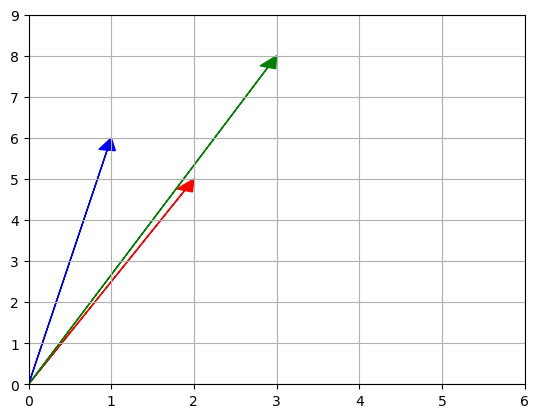

Part B
Left Side:  [15 39]
Right Side:  [15 39]
Are they equal?  True
Part C
Normalized u:  [0.37139068 0.92847669]
Part D
Dot Product of u and v:  46
Angle between u and v (radians):  0.02173570684178708
Angle between u and v (degrees):  1.2453642667680276
Part E
Cosine Similarity of u and w:  0.9769000173962618
Part F


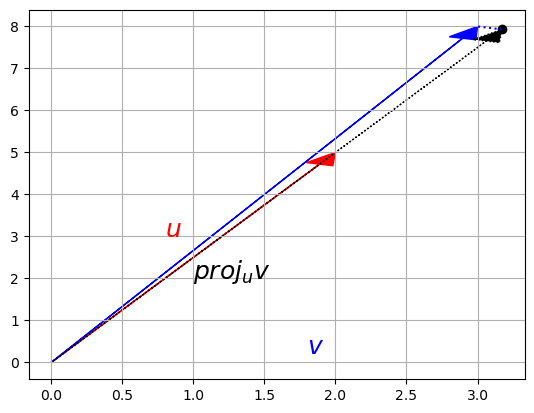

In [3]:
import numpy as np
import matplotlib.pyplot as plt


print("Part A")
#create vectors u,v,w
u = np.array([2,5])
v = np.array([3,8])
w = np.array([1,6])

#method to visualie vectors in 2D
def plot_vector2d(vector2d,  origin = [0, 0], **options):
    return plt.arrow(origin[0], origin[1], vector2d[0], vector2d[1],
              head_width = 0.2, head_length = 0.3, length_includes_head = True,
              **options)
#plot u,v,w
plot_vector2d(u, color = 'r')
plot_vector2d(v, color = 'g')
plot_vector2d(w, color = 'b')
plt.xlim(0,6)
plt.ylim(0,9)
plt.grid()
plt.show()

print("Part B")
#verify scalar multiplication is distributive
scalar = 3
left_side = scalar * (u + v)
right_side = scalar * u + scalar * v
print("Left Side: ", left_side)
print("Right Side: ", right_side)
print("Are they equal? ", np.array_equal(left_side, right_side))

print("Part C")

#find normalized vector of u
normalized_u = u/np.linalg.norm(u)
print("Normalized u: ", normalized_u)

print("Part D")

#dot product between u and v
dot_product = np.dot(u,v)
print("Dot Product of u and v: ", dot_product)
#angle between u and v
cos_theta = dot_product / (np.linalg.norm(u) * np.linalg.norm(v))
vector_angle = np.clip(cos_theta, -1.0, 1.0)
thetha_radians = np.arccos(vector_angle)
thetha_degrees = np.degrees(thetha_radians)
print("Angle between u and v (radians): ", thetha_radians)
print("Angle between u and v (degrees): ", thetha_degrees)

print("Part E")

#find cosine similarity of w with respect to u and v
cosine_similarity_uw = np.dot(u,w) / (np.linalg.norm(u) * np.linalg.norm(w))
print("Cosine Similarity of u and w: ", cosine_similarity_uw)

print("Part F")
#find projection vector of u onto v
u_normalized = u / np.linalg.norm(u)
proj = v.dot(u_normalized) * u_normalized

plot_vector2d(u, color="r")
plot_vector2d(v, color="b")

plot_vector2d(proj, color="k", linestyle=":")
plt.plot(proj[0], proj[1], "ko")

plt.plot([proj[0], v[0]], [proj[1], v[1]], "b:")

plt.text(1, 2, "$proj_u v$", color="k", fontsize=18)
plt.text(1.8, 0.2, "$v$", color="b", fontsize=18)
plt.text(0.8, 3, "$u$", color="r", fontsize=18)

plt.grid()
plt.show()

** Written Portion**

E: Cosine simlilarity tells how similiar vectors are to eachother. We can see with a similiarty of almost one, these vectors are very similar to eachother.

F: We can see that the vectors are going almost the same direction, however U is shorter than v and has a slightly different angle. This matches our cosine similiarty as they are almost going the same direction. This tells us these vectors are very similiar.

In [26]:
time_tracker()

Wed Feb  4 12:35:31 2026


### Question 2 (6 x 3 = 18 points): 

Consider 4 X 3  matrix **A** with the following entries:
   
   
 
  \begin{bmatrix} 
     2 &  3 &     5\\                      
     9  & 6 &   7 \\   
     4  & 10 &    11 \\    
     4 & 8 & 12 \\
 \end{bmatrix} and 3 X 4  matrix **B** with the following entries:
   
  \begin{bmatrix} 
     1 &  3 &     5 &      -4\\                    
     -9  & 2 &   6  &     8\\
     4  & 5 &    11 &      -12
 \end{bmatrix}
  
  
  
(a) Find $A-5B$ and AB and $A^TB$ if those operations possible. If not possible, explain the related issues.

(b) Find  the transpose matrix $A^T$ and calculate matrix multiplication $ A^TA$. Save the result as matrix $C$ ( **Hint**: Find the dot prduct of $A^T$ and $A$). Find the transpose of C. Is the matrix $C$  a symetric matrix? Is the matrix C square shape?

(c) Find the **Determinant** of C. Is C a singular(non-invertible) matrix? Explain. Also, find **Trace** of C. 

(d) Find the eigven values and eigen vectors of the matrix $C = A^TA$.

(e) Recall the **Singular Value Decomposition**

Any  $m \times n$ matrix $A$ can be decomposed into the dot product of three simple matrices:
* A rotation matrix $U$ (an $m \times m$ orthogonal matrix)
* A scaling & projecting matrix $\Sigma$ (an $m \times n$ diagonal matrix consisting the singular values $ \sigma_i = \sqrt{\lambda_i}$, where $ \lambda_i$ are the eigen values of $A^TA$. 

* And another rotation matrix $V^T$ (an $n \times n$ orthogonal matrix)

Then we can write $ A = U \cdot \Sigma \cdot V^{T}$

Find the singular value decomposition of matrix **A**. Display three different components of the decompositions: $U$, $\Sigma$, and $V^T$


(f) What is the relationship of singular values of A and eigenvalues of $A^TA$? Explain with numerical evidence.
  

In [ ]:


print("Part A")
#create matrix A as a 4x3
A = np.array([[2,3,5],
              [9,6,7],
              [4,10,11],
              [4,8,12]])
#create b as a 3x4 matrix
b = np.array([[1,3,5,-4],
              [-9,2,6,8],
              [4,5,11,-12]])
#find a-5b or explain why not possible
print("Result of A - 5B is not possible due to shape difference and subtraction.")
#find AB or explain why not possible
result_AB = A.dot(b)
print("Result of AB:\n", result_AB)
#find A^T B or explain why not possible
print("Result of A^T B is not possible due to shape because of multiplication rules.")

print("Part B")
#find transpose of A^T
print("Transpose of A (A^T):\n", A.T)
#find A^T A
c = A.T.dot(A)
print("Result of A^T A:\n", c)
#is c symmetric?
is_symmetric = np.array_equal(c, c.T)
print("Is c symmetric? ", is_symmetric)
#is c square shaped?
is_square = c.shape[0] == c.shape[1]
print("Is c square shaped? ", is_square)

print("Part C")
#find determinite of c
det_c = np.linalg.det(c)
print("Determinant of c: ", det_c)
#is c invertible?
is_invertible = det_c != 0
print("Is c invertible? ", is_invertible)


print("Part D")
#find eigenvalues and eigenvectors of C A^T Alues)
eigenvalues, eigenvectors = np.linalg.eig(c)
print("Eigenvalues of c:\n", eigenvalues)
print("Eigenvectors of c:\n", eigenvectors)

print("Part E")
#find singular decomposition of A
#https://numpy.org/doc/stable/reference/generated/numpy.linalg.svd.html
U, S, VT = np.linalg.svd(A)
sigma = np.zeros((A.shape[0], A.shape[1]))
sigma[:len(S), :len(S)] = np.diag(S)
#print U, Sigma, VT
print("U:\n", U)
print("Sigma:\n", sigma)
print("V^T:\n", VT)

print("Part F")

# find eigenvalues of c using eigh (since c is symmetric)
eigvals_c = np.linalg.eigvalsh(c)

# compare with squared singular values of A
eigvals_sorted = np.sort(eigvals_c)
sing_sq_sorted = np.sort(S**2)

print("Eigenvalues of A^T A after sorting:\n", eigvals_sorted)
print("Squared singular values of A after sorting:\n", sing_sq_sorted)
print("Do they match? ", np.allclose(eigvals_sorted, sing_sq_sorted))



Part A
Result of A - 5B is not possible due to shape difference and subtraction.
Result of AB:
 [[ -5  37  83 -44]
 [-17  74 158 -72]
 [-42  87 201 -68]
 [-20  88 200 -96]]
Result of A^T B is not possible due to shape because of multiplication rules.
Part B
Transpose of A (A^T):
 [[ 2  9  4  4]
 [ 3  6 10  8]
 [ 5  7 11 12]]
Result of A^T A:
 [[117 132 165]
 [132 209 263]
 [165 263 339]]
Is c symmetric?  True
Is c square shaped?  True
Part C
Determinant of c:  56312.999999999774
Is c invertible?  True
Part D
Eigenvalues of c:
 [631.65949071  30.40875926   2.93175003]
Eigenvectors of c:
 [[ 0.37979036  0.92244086  0.06972903]
 [ 0.57133343 -0.17461201 -0.80192815]
 [ 0.72755577 -0.34440311  0.59333726]]
Part E
U:
 [[-0.24316236  0.07271305  0.40903248 -0.87651429]
 [-0.47503608 -0.87832979 -0.01789872  0.05056813]
 [-0.60620332  0.3345398  -0.7088135  -0.13484835]
 [-0.58968664  0.33366556  0.57441752  0.4593272 ]]
Sigma:
 [[25.1328369   0.          0.        ]
 [ 0.          5.51441377

** Written Portion **
C: C has a deterininate of greater than zero, so it is invertable.
F: Singular values of A are square roots of the eigen values of AtA. We can see this because after squaring the singular values and comparing them to the eigen values we can see that they are identical.


### **Problem 3 (6 x 3 = 18 points)**:

Use numpy to create 4 X 5  matrix A with the following entries:
   
   
 
  \begin{bmatrix} 
     1 &  3 &     5  & 2 \\                      
     2  & 6 &   7 &  4 \\   
     3  & 10 &    11 &   6\\    
     4 & 8 & 12 &    8\\
 \end{bmatrix}
  
  
  
 and 4 X 4  matrix B with the following entries:
   
  \begin{bmatrix} 
     1 &  3 &     5 &      -4\\                    
     -9  & 2 &   6  &     8\\
     4  & 5 &    11 &      -12\\
    3   &  2 &   3 &   8\\  
    4 &  8 & 7 & 8\\
 \end{bmatrix}
 

(a) Find rank of A and B. Is matrix A full rank matrix? What about B? If any of these matrices is rank deficient, what are the possible reasons for rank difficiency? What can you say about underlying features if the matrix is a design matrix? 



(b) Calculate condition numbers of A and B. Which one of them is relatively well-conditioned compared to other?

(c) Find siggular values of A and B and calculate respective condition numbers of A and B using respective singular values.Compare these answers with the answers from (b).

(d) What is the relationship between singular values and rank of the matrix?

(e) Discuss the matrix conditioning based on singular values. Why there an impact of smaller singular values in determining matrix conditioning? 

(f) Given two matrices look similar in terms of their sizes and entries, however, there is a significant diffeerece in the matrix conditioning. What can you say about the possible outocomes (preditions) obtained from these matrices? 

In [ ]:
#create matrix a with dimensions 4x4????
A = np.array([
    [1,  3,  5,  2],
    [2,  6,  7,  4],
    [3, 10, 11,  6],
    [4,  8, 12,  8]
])

#create matrix B as 5x4
B = np.array([
    [ 1,  3,  5,  -4],
    [-9,  2,  6,   8],
    [ 4,  5, 11, -12],
    [ 3,  2,  3,   8],
    [ 4,  8,  7,   8]
])


print("Part A")
# find rank of A and B
rank_A = np.linalg.matrix_rank(A)
rank_B = np.linalg.matrix_rank(B)
print("Rank of A: ", rank_A)
print("Rank of B: ", rank_B)

print("Part B")

#calculate the condition numbers of A and B
cond_A = np.linalg.cond(A)
cond_B = np.linalg.cond(B)
print("Condition number of A: ", cond_A)
print("Condition number of B: ", cond_B)

print("Part C")

#find singular values of A and B
singular_values_A = np.linalg.svd(A)
singular_values_B = np.linalg.svd(B)
#calculate condition values using singular values
cond_A_svd = singular_values_A[1][0] / singular_values_A[1][-1]
cond_B_svd = singular_values_B[1][0] / singular_values_B[1][-1]
print("Condition number of A using SVD: \n", cond_A_svd)
print("Condition number of B using SVD: \n", cond_B_svd)
print("Singular values of A:\n", singular_values_A[1])
print("Singular values of B:\n", singular_values_B[1])






Part A
Rank of A:  3
Rank of B:  4
Part B
Condition number of A:  4.172379573222642e+17
Condition number of B:  9.29879670265604
Part C
Condition number of A using SVD:  4.1723795732226406e+17
Condition number of B using SVD:  9.29879670265605
Singular values of A:
 [2.63036833e+01 2.25366096e+00 1.01845916e+00 6.30424025e-17]
Singular values of B:
 [19.54676885 18.21523998 10.13460115  2.10207508]


** Written Portion **

A: Matrix A is a full rank matrix as there are no obvious dependecies between rows and colums, and we can confirm this as the rank we get out is 4 from our code. B is also full rank, as we cannot see dependecies, and we also get out 4 from our code, the maximum rank for our matrix, even though its 5x4 as 4 is still the highest rank. If it is a design matrix, all the features are independant and have unique information.

B:  A is better conditioned then B as its more than half of its condition value.

D: The rank of the matrix is the number of non singular values.

E: Matrix ranking is from the ration of biggest to smallest singular values. It is well conditioned when the singular values are close to the same value, and it is ill conditioned when even one singular values is close to zero.

F: Even if they look similar, if they have a difference in thier conditioning values it means the matrix with the lower value is going to output less table and less reliable outcomes then the matrix that is better conditioned.

## Part II:  Statistical Analysis of Titanic Disaster


### Learning outcomes.

- Load data from Library

- Data preprocessing such as data cleaning, filtering, feature extractions, data manipulation, data ranking, and grouping.
- Performing exploratory data analysis and visualization. 
- Making statistical inference for population parameter.
- Hypothesis testing.

### Data: Titanic data

This dataset has key information about the aftermath of historic titanic disaster in 15 April 1912 in the North Atlantic Ocean. We will be using one version of dataset which can be found in **Seaborn** library. 


### **Question 4 (5 points)**.

Perform the following tasks. It is recommended to answer each of the following questions in a separate jupyter cell. You can create additional markdown cell for interpretation if needed. 

- Import seaborn library in jupyter and load **titanic** dataset from this library. Give the name of this dataframe as **titanic_data**.  Use head() and tail() functions to see some of the few rows. 
          
   Hint: 
         
          titanic_data = sns.load_dataset("titanic")


- What are the index and features (column names) in the dataset? Display what type of data is there in each column (**Hint**: info() function might be helpful).

- Provide a statistical summary of the data.


- What was the average ticket price ("fare") of the trip (in US dollar)? 


In [ ]:
import seaborn as sns

#import titanic data set
titanic_data = sns.load_dataset('titanic')

#print the head and tail of the data set
print("Head of Titanic Data Set:\n", titanic_data.head())
print("Tail of Titanic Data Set:\n", titanic_data.tail())

#display the index and features of the data set
print("Titanic Data Set Features:\n", titanic_data.columns)
print("Titanic Data Set Index:\n", titanic_data.index)
#display data types
print("Titanic Data Set Data Types:\n", titanic_data.dtypes)

#display statistical summary of the data set
print("Statistical Summary of Titanic Data Set:\n", titanic_data.describe())

#what was the average ticket price
average_ticket_price = titanic_data['fare'].mean()
print("Average Ticket Price in USD: ", average_ticket_price.round(2))


Head of Titanic Data Set:
    survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
Tail of Titanic Data Set:
      survived  pclass     sex   age  sibsp  parch   fare embarked   class  \
886         0       2    male  27.0      0      0  13.00        S  Second   
887        

### **Question 5(5 points)** 

Answer the following questions.

- Create two subsets namely **survived_data** and **unsurvived_data**  by selecting the appropriate rows from the **titanic_data** set. Use head() and tail() functions to view few rows of these datasets. **Hint**: 
      
       survived_data = titanic_data[titanic_data['survived'] == '1']
       
       
 How many passengers were survived in that historic disaster? 
 
      

In [46]:
# subset of people who survived
survived_data = titanic_data[titanic_data['survived'] == 1]
#people who did not survive
not_survived_data = titanic_data[titanic_data['survived'] == 0]

#prevuew survived and not survived
print("Head of Survived Data Set:\n", survived_data.head())
print("Head of Not Survived Data Set:\n", not_survived_data.head())
print("Tail of Survived Data Set:\n", survived_data.tail())
print("Tail of Not Survived Data Set:\n", not_survived_data.tail())

#how many people survived?
print("Number of People who Survived: ", len(survived_data))

Head of Survived Data Set:
    survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
1         1       1  female  38.0      1      0  71.2833        C   First   
2         1       3  female  26.0      0      0   7.9250        S   Third   
3         1       1  female  35.0      1      0  53.1000        S   First   
8         1       3  female  27.0      0      2  11.1333        S   Third   
9         1       2  female  14.0      1      0  30.0708        C  Second   

     who  adult_male deck  embark_town alive  alone  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
8  woman       False  NaN  Southampton   yes  False  
9  child       False  NaN    Cherbourg   yes  False  
Head of Not Survived Data Set:
    survived  pclass   sex   age  sibsp  parch     fare embarked  class    who  \
0         0       3  male  22.0      1      0   7.2500        S  Third  


 
### **Question 6(5 points)** 

Determine whether there are any missing values in the **age** column of two data sets. If there are missing values, use appropriate strategy to handle these missing values and make these data sets cleaned. Use either **matplotlib** or **seaborn** library to create two histograms of the **age** column of the **survived_data** and **unsurvived_data**. You can put two subplots side-by-side in a single frame. Interpret the results.
              
         

There are people without an age in the survived dataset.
There are people without an age in the not survived dataset.


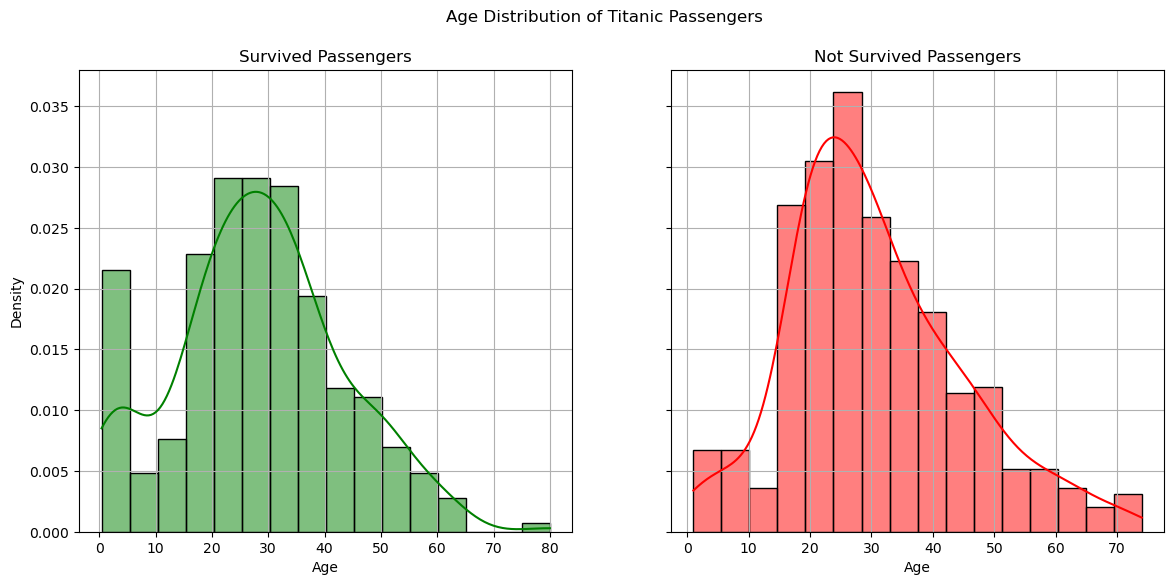

In [47]:
#are there people without and age in either dataset
if(survived_data['age'].isnull().sum()) > 0:
    print("There are people without an age in the survived dataset.")
    #clean the survived dataset
    survived_data = survived_data.dropna(subset=['age'])
if(not_survived_data['age'].isnull().sum()) > 0:
    print("There are people without an age in the not survived dataset.")
    #clean the not survived dataset
    not_survived_data = not_survived_data.dropna(subset=['age'])


#seaborn plot age of both datasets, two histograms in the same frame
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

sns.histplot(survived_data['age'], color='g', label='Survived', kde=True, stat="density", ax=axes[0])
axes[0].set_title('Survived Passengers')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Density')
axes[0].grid(True)

sns.histplot(not_survived_data['age'], color='r', label='Not Survived', kde=True, stat="density", ax=axes[1]) 
axes[1].set_title('Not Survived Passengers')
axes[1].set_xlabel('Age')
axes[1].grid(True)

fig.suptitle('Age Distribution of Titanic Passengers')
plt.show()

According to our code, we know that there are people without an gae in both datasets.  And looiking at the histogram, we can see the biggest difference in the ages of people who survived and who did not survive is that significantly more infants survided that died. There are also some spikes indicating that more people around the age of 20 and 30 died.



### **Question 7(10 points)**

As we understand from history of titanic disaster, there were several hundereds(if not thousands) more passengers in the ship compared to the data that we have now. Therefore, we can consider our data sets as samples. 


Consider the following assumptions.


- **Population**:  Distribution of ages of all passengers who survived.
 
- **Population parameter = population mean ($\mu$)**: Average age of all survived passengers. 


Perform the following tasks to provide the point estimate for the population mean and its confidence interval using  first **traditional method** and then the method of  **bootstrapping**. Compare your results.  



### Traditional Method

- Calculate the sample mean $\bar{x}$ as point estimate. You can re-create sample of smaller size(say 100)  by randomly selecting observations from the data set Or use the entire data set.

- Create 90\% confidence interval based on your sample. **Hint**: z-score for two sided 90% CI:  1.645


In [ ]:
# get the sample mean
sample_mean_survived = survived_data['age'].mean()
print("Sample Mean Age of Survived Passengers: ", sample_mean_survived.round(2))

#confidence intervals for mean age of survived passengers
xbar = survived_data['age'].mean()
s = survived_data['age'].std(ddof=1)
n = int(len(survived_data['age']))
z = 1.645
ci_trad = (xbar - z * s/np.sqrt(n), xbar + z * s/np.sqrt(n))

print("Traditional:")
print("mean =", xbar)
print("90% CI =", ci_trad)


Sample Mean Age of Survived Passengers:  28.34
Traditional:
mean = 28.343689655172415
90% CI = (np.float64(26.899461690322134), np.float64(29.787917620022696))

Bootstrap:
mean ≈ 28.346940468965517
90% CI = (np.float64(26.883687931034483), np.float64(29.797475862068968))

Compare:
Traditional CI width = 2.8884559297005623
Bootstrap CI width   = 2.9137879310344843


### Bootstrapping Method

Select 1000 bootstrapped samples of size 100 for each sample and construct  90%  confidence interval using the estimates(mean or median) obtained from those samples. Compare your results with that obatined from traditional method.

In [56]:
# bootstrap confidence intervals for mean age of survived passengers
B = 1000
sample_size = 100

boot_means = []

for _ in range(B):
    sample = np.random.choice(survived_data['age'], size=sample_size, replace=True)
    boot_means.append(sample.mean())

boot_means = np.array(boot_means)

ci_boot = (np.percentile(boot_means, 5),
           np.percentile(boot_means, 95))

print("Bootstrap:")
print("mean ≈", boot_means.mean())

#compare bootstrap CI to traditional CI
print("90% CI (Bootstrap) =", ci_boot)
print("90% CI (Traditional) =", ci_trad)
#difference between the two methods
diff_lower = ci_boot[0] - ci_trad[0]
diff_upper = ci_boot[1] - ci_trad[1]
print("Difference in Lower Bound: ", diff_lower)
print("Difference in Upper Bound: ", diff_upper)

Bootstrap:
mean ≈ 28.3457971
90% CI (Bootstrap) = (np.float64(26.03024), np.float64(30.755335))
90% CI (Traditional) = (np.float64(26.899461690322134), np.float64(29.787917620022696))
Difference in Lower Bound:  -0.869221690322135
Difference in Upper Bound:  0.9674173799773023


### **Question 8(10 points)**: 

Check necessary assumptions and test the following two-sample  hypothesis by using 95% confidence interval (i.e. significance level $\alpha = 0.05$).

**Population 1**:  Distribution of ages of all passengers who survived. You can use **survived__data** as a sample from this population. 

**Population 2**: Distribution of ages of all passengers who did not survived. You can use **unsurvived__data** as a sample from this population. 





   - $H_0: \mu_{survived\_age} = \mu_{unsurvived\_age} $: There was no difference of passengers age in terms of who survived and who did not in titanic disaster. That means passengers age had no impact in the survival.
 
 
 
   - $H_A: \mu_{survived\_age} \neq \mu_{unsurvived\_age}$: There was a significant difference in the passengers age in two population groups. 
   
   
 
  
  
Before performing hypothes testing. Frist,test the following assumptions. 
   
   
   

### Assumption1: Checking Normaliy Assumption

$$H_0: Distribution \, of \,  age\, follows\, normal\,  distribution$$

$$H_a: Distributionis\, is\, not\, normal $$

Based on looking at the graph that we created above, the data does not look normal and we are going to have to assume that Ha is true, the distrobutions do not follow a normal distubtion. We can see that the data is skewed.

### Assumption 2:  Checking Variances (equal variances or unequal variances?)

In [64]:
#standard deviation of ages in both datasets
print("Standard deviation (Survived):", survived_data['age'].std(ddof=1))
print("Standard deviation (Not Survived):", not_survived_data['age'].std(ddof=1))


Standard deviation (Survived): 14.950951984140426
Standard deviation (Not Survived): 14.172109877138494


We can see that the variances are equal due to how similar the standard deviation is between the two datasets.

### Performing Two-sample T-test

Based on our investigation of the necessary assumptions (normalily test of the distributions  and the understanding of variances), we will perform two sample t-test.

Reference: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html



In [ ]:
#two sample t test on bith datasets
from scipy import stats
t_stat, p_value = stats.ttest_ind(survived_data['age'], not_survived_data['age'], equal_var=False)
print("Two Sample t-test Results:")
print("t-statistic: ", t_stat)
print("p-value: ", p_value)

Two Sample t-test Results:
t-statistic:  -2.0460301043939704
p-value:  0.04118965162586641


## Part III: Problem Exploration/Expansion


### **Question 9 (5 points)**.

Based on your short exploration of this particular data so far, answer the following. 

- What type of predictive models(machine learning models) might be appropriate in this problems? 

- What can be the most appropriate variable as a response variable so that it's values may be predicted by using such models? 

- Based on your knowledge, whether your models will be regression models (often used for predicting continuous variable) or classification models(predicting classes or categories) or something else?


Superviesed learning models are the best for this dataset and problem. We have labled outcomes of who survived and who didnt, and we are trying to build a relationship between the data we have and the outcome of if they survived.

Survival makes the most sense, as it is the ultimate outcome of the passenges, there are only two options, and we can use the other data to predict this outcome.

Since we are predicting survival, it is categorical and either true or false. This makes classification models the best option.